# Classificação de Texto com Keras/TensorFlow — Dataset Reuters

Projeto **ponta a ponta** usando um dos datasets padrão do `keras.datasets`:

**dados → pré-processamento → modelo → treino → validação → teste → inferência**

### Sobre o dataset (Reuters-21578)

O **Reuters Newswire Classification** vem do clássico corpus **Reuters-21578**
(split ApteMod): **11.228 notícias** curtas da agência Reuters do início dos
anos **1980/90**. Cada notícia é classificada em um dos **46 tópicos** —
ex.: `earn` (lucros), `acq` (fusões/aquisições), `crude` (petróleo),
`trade` (comércio), `grain` (grãos), ...

Características importantes para o projeto:

- **Vocabulário datado**: as palavras são da década de 1980-90 (ex.: `mln`, `pct`,
  `dlrs`). Textos modernos trazem palavras fora do vocabulário (OOV).
- **Classes desbalanceadas**: poucos tópicos concentram a maioria das notícias
  (≈ 1/3 é `earn`); classes raras têm poucos exemplos até no teste.
- **Tamanho variável**: cada notícia tem um número diferente de palavras, o que
  exige o *padding* do pré-processamento.

Aqui vamos construir uma rede neural profunda em Keras/TensorFlow que aprende a
classificar notícias — tudo com pouco código e muita matemática!

**Não há mágica, há matemática!**

> **Ambiente:** notebook desenvolvido para rodar no **Google Colab**.
> O TensorFlow já vem instalado; as demais bibliotecas são instaladas na célula seguinte.

**Dependências:** `tensorflow`, `numpy`, `matplotlib`, `seaborn`, `scikit-learn`

In [1]:
import sys
if "google.colab" not in sys.modules:
    raise RuntimeError("Este notebook deve ser executado no Google Colab.")
print("Ambiente Colab OK.")

Ambiente Colab OK.


In [2]:
# Garantir as dependências instaladas (todas já vêm com o Colab).
!pip install -q matplotlib seaborn scikit-learn

# IMPORTANTE: nunca rodar "pip install -U numpy" neste notebook. O Colab já traz o
# numpy compatível com numba/scipy/pandas; um numpy >= 2.3 quebra o scipy do Colab
# (erro "_blas_supports_fpe" ao importar seaborn). Se detectarmos numpy >= 2.3,
# rebaixamos automaticamente para < 2.3 na primeira execução.
import subprocess, sys
from importlib.metadata import version as _pkg_version

_numpy_ver = tuple(map(int, _pkg_version("numpy").split(".")[:2]))
print("numpy detectado:", ".".join(map(str, _numpy_ver)))

if _numpy_ver >= (2, 3):
    print("Rebaixando numpy para < 2.3 (compatível com numba/scipy do Colab)...")
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "numpy<2.3"],
        check=True,
    )
    sys.exit("Numpy corrigido para < 2.3. Execute agora: Runtime > Restart session (ou Disconnect and delete runtime) e rode o notebook novamente.")

import numpy as np
print("Versão final do numpy:", np.__version__)

for _lib in ["matplotlib", "seaborn", "scikit-learn", "tensorflow"]:
    print(_lib + ":", _pkg_version(_lib))
print("Ambiente OK.")

numpy detectado: 2.1
Versão final do numpy: 2.1.3
matplotlib: 3.10.0
seaborn: 0.13.2
scikit-learn: 1.6.1
tensorflow: 2.20.0
Ambiente OK.


In [3]:
# Imports gerais
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Keras / TensorFlow
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.datasets import reuters

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)

TensorFlow: 2.20.0
Keras: 3.13.2


## 1. Carregamento dos dados

O Keras baixa e prepara o dataset automaticamente. O parâmetro `num_words=10000`
limita o vocabulário às **10.000 palavras mais frequentes** — mantém o problema
enxuto e descarta palavras raras (que pouco ajudam na classificação).

#### A "compressão": como um texto vira números

Uma rede neural não "lê" texto — ela consome **números**. O gerador do dataset
aplica uma compressão simples e **reversível** da notícia:

1. Cada palavra única do corpus ganha um número pela **frequência**: a mais comum
   vira `1`, a segunda `2`, e assim por diante (é o dicionário `word_index`).
2. Mantêm-se apenas as palavras entre as **10.000 mais frequentes**
   (`num_words=10000`); as demais viram um código de "palavra desconhecida".
3. Alguns índices ficam **reservados**: `0` = *padding* (preenche textos curtos),
   `1` = início do texto, `2` = fora do vocabulário (OOV).
4. Nos dados de treino soma-se **+3** aos índices reais — `'the'` tem índice `1` e
   aparece como `4` na sequência — deixando os três reservados livres.

Exemplo: `"the firm bought ..."` → índices do `word_index` → **+3** →
`[1, 4, 12, ...]` (o `1` marca o início do texto).

O passo reverso (**decodificação**, seção 2) subtrai 3 e procura a palavra no
dicionário invertido; palavras desconhecidas aparecem como `?`.
É essa codificação que a função `decode_newswire()` (seção 2) e a
`encode_newswire()` (seção 7.1) usam para ler/escrever notícias.

In [4]:
NUM_WORDS = 10000  # tamanho do vocabulário considerado

(x_train, y_train), (x_test, y_test) = reuters.load_data(num_words=NUM_WORDS)
print("Dataset carregado!")

# Nomes dos 46 tópicos (índice -> nome), na mesma ordem dos rótulos y
label_names = reuters.get_label_names()

def topic_name(i):
    return label_names[i]

print("Mapeamento índice -> tópico:")
for _i, _name in enumerate(label_names):
    print(f"  {_i:2d} -> {_name}")

2110848/2110848 ━━━━━━━━━━━━━━━━━━━━ 1s 1us/step
Dataset carregado!
Mapeamento índice -> tópico:
   0 -> cocoa
   1 -> grain
   2 -> veg-oil
   3 -> earn
   4 -> acq
   5 -> wheat
   6 -> copper
   7 -> housing
   8 -> money-supply
   9 -> coffee
  10 -> sugar
  11 -> trade
  12 -> reserves
  13 -> ship
  14 -> cotton
  15 -> carcass
  16 -> crude
  17 -> nat-gas
  18 -> cpi
  19 -> money-fx
  20 -> interest
  21 -> gnp
  22 -> meal-feed
  23 -> alum
  24 -> oilseed
  25 -> gold
  26 -> tin
  27 -> strategic-metal
  28 -> livestock
  29 -> retail
  30 -> ipi
  31 -> iron-steel
  32 -> rubber
  33 -> heat
  34 -> jobs
  35 -> lei
  36 -> bop
  37 -> zinc
  38 -> orange
  39 -> pet-chem
  40 -> dlr
  41 -> gas
  42 -> silver
  43 -> wpi
  44 -> hog
  45 -> lead


## 2. Visualização de dados

Antes de treinar, vamos **olhar** os dados: formas, rótulos, tamanhos e algumas
amostras decodificadas (índices → palavras reais).

In [5]:
print("Formato de x_train:", x_train.shape, "| x_test:", x_test.shape)
print("Formato de y_train:", y_train.shape, "| y_test:", y_test.shape)

num_classes = len(np.unique(np.concatenate([y_train, y_test])))
print("Número de tópicos (classes):", num_classes)

print()
print("x_train[0] (índices das palavras):", x_train[0][:15], "...")
print("y_train[0] (tópico):", y_train[0], "->", topic_name(y_train[0]))

Formato de x_train: (8982,) | x_test: (2246,)
Formato de y_train: (8982,) | y_test: (2246,)
Número de tópicos (classes): 46

x_train[0] (índices das palavras): [1, 2, 2, 8, 43, 10, 447, 5, 25, 207, 270, 5, 3095, 111, 16] ...
y_train[0] (tópico): 3 -> earn


In [6]:
# Mapear índice -> palavra (para "ler" as notícias de volta)
word_index = reuters.get_word_index()
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])

def decode_newswire(sequence):
    # Índices 0, 1 e 2 são reservados (padding, início e palavra desconhecida)
    return " ".join([reverse_word_index.get(i - 3, "?") for i in sequence])

print("Primeira notícia de treino decodificada:")
print()
print(decode_newswire(x_train[0]))

550378/550378 ━━━━━━━━━━━━━━━━━━━━ 1s 2us/step
Primeira notícia de treino decodificada:

? ? ? said as a result of its december acquisition of space co it expects earnings per share in 1987 of 1 15 to 1 30 dlrs per share up from 70 cts in 1986 the company said pretax net should rise to nine to 10 mln dlrs from six mln dlrs in 1986 and rental operation revenues to 19 to 22 mln dlrs from 12 5 mln dlrs it said cash flow per share this year should be 2 50 to three dlrs reuter 3


In [9]:
# Exemplo de uma notícia COMPLETA do treino (sem truncamento)
idx = 0  # troque o índice para ver outras notícias
print(f"Notícia completa #{idx} — tópico: {y_train[idx]} ({topic_name(y_train[idx])})")
print(f"Número de palavras codificadas: {len(x_train[idx])}")
print("=" * 70)
print(decode_newswire(x_train[idx]))

Notícia completa #0 — tópico: 3 (earn)
Número de palavras codificadas: 87
? ? ? said as a result of its december acquisition of space co it expects earnings per share in 1987 of 1 15 to 1 30 dlrs per share up from 70 cts in 1986 the company said pretax net should rise to nine to 10 mln dlrs from six mln dlrs in 1986 and rental operation revenues to 19 to 22 mln dlrs from 12 5 mln dlrs it said cash flow per share this year should be 2 50 to three dlrs reuter 3


In [10]:
# Algumas amostras aleatórias de treino
import random
random.seed(42)

for idx in random.sample(range(len(x_train)), 5):
    print(f"--- Amostra {idx} | tópico {y_train[idx]} ({topic_name(y_train[idx])}) | {len(x_train[idx])} palavras ---")
    print(decode_newswire(x_train[idx])[:280])
    print()

--- Amostra 1824 | tópico 3 (earn) | 71 palavras ---
? shr 1 46 dlrs vs 1 41 dlrs net 277 5 mln vs 268 3 mln sales 2 13 billion vs 2 14 billion avg shrs 189 8 mln vs 189 8 mln nine mths shr 3 95 dlrs vs 3 78 dlrs net 750 5 mln vs 718 4 mln sales 6 28 billion vs 6 22 billion avg shrs 189 9 mln vs 190 2 mln reuter 3

--- Amostra 409 | tópico 3 (earn) | 17 palavras ---
? qtly div 10 cts vs 10 cts prior pay april 15 record april one reuter 3

--- Amostra 4506 | tópico 16 (crude) | 101 palavras ---
? marathon petroleum company a subsidiary of usx corp said it lowered posted prices for crude oil by 50 cts with an effective date of october 16 the increase brings posted prices for west texas intermediate and west texas sour to 19 00 dlrs a barrel each south louisiana sweet was

--- Amostra 4012 | tópico 9 (coffee) | 77 palavras ---
? zimbabwe's projected coffee output of 13 000 tonnes for 1987 88 could be reduced by drought growers said the main coffee growing areas in eastern zimbabwe have re

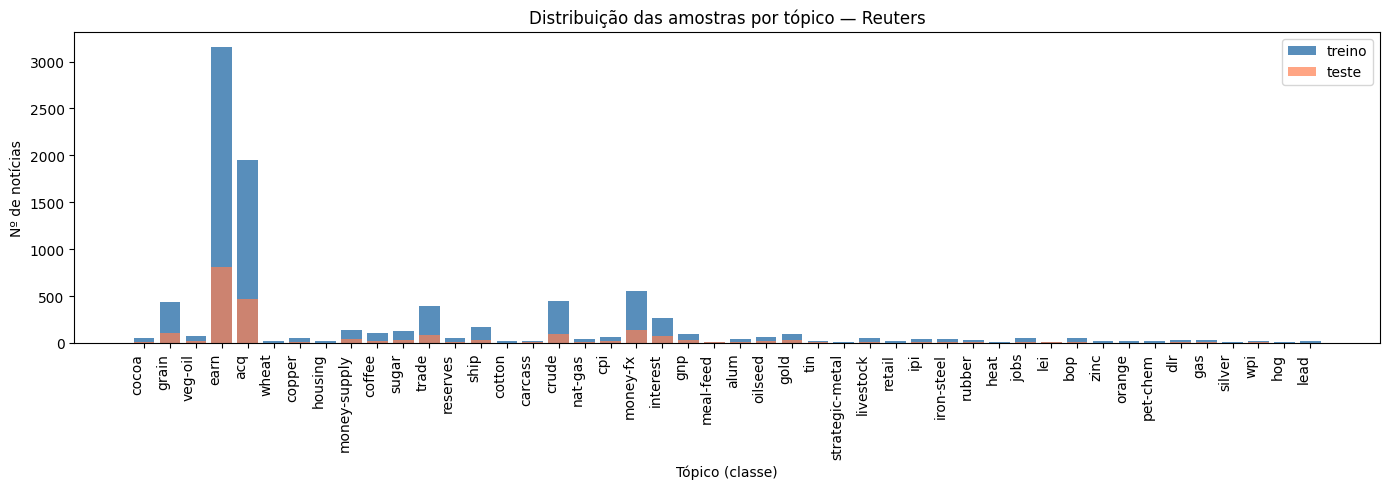

Notícias de treino: 8982 | Notícias de teste: 2246


In [11]:
# Distribuição das amostras por tópico (treino e teste)
train_topics, train_counts = np.unique(y_train, return_counts=True)
test_topics, test_counts = np.unique(y_test, return_counts=True)

plt.figure(figsize=(14, 5))
plt.xticks(train_topics, [topic_name(t) for t in train_topics], rotation=90, ha="right")
plt.bar(train_topics, train_counts, color="steelblue", alpha=0.9, label="treino")
plt.bar(test_topics, test_counts, color="coral", alpha=0.7, label="teste")
plt.xlabel("Tópico (classe)")
plt.ylabel("Nº de notícias")
plt.title("Distribuição das amostras por tópico — Reuters")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Notícias de treino: {len(y_train)} | Notícias de teste: {len(y_test)}")

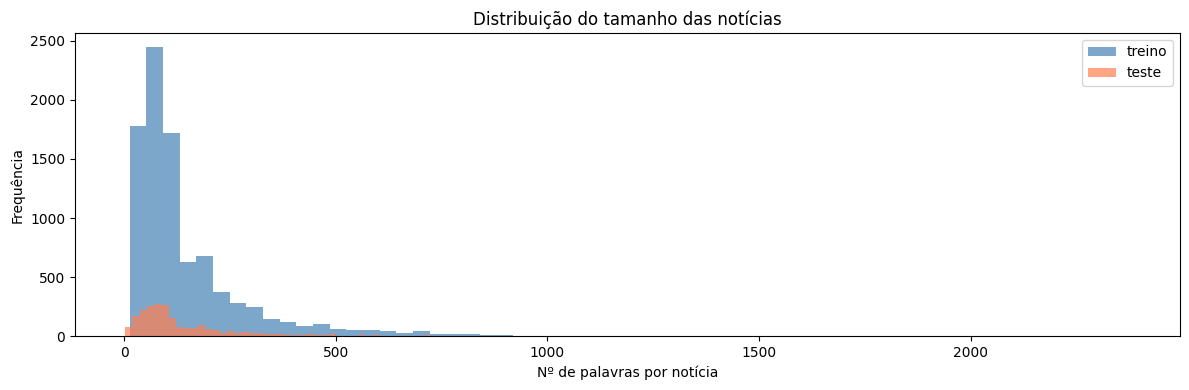

Comprimento médio (treino): 145.5 palavras


In [12]:
# Distribuição do tamanho (nº de palavras) das notícias
lens_train = [len(s) for s in x_train]
lens_test = [len(s) for s in x_test]

plt.figure(figsize=(12, 4))
plt.hist(lens_train, bins=60, alpha=0.7, label="treino", color="steelblue")
plt.hist(lens_test, bins=60, alpha=0.7, label="teste", color="coral")
plt.xlabel("Nº de palavras por notícia")
plt.ylabel("Frequência")
plt.title("Distribuição do tamanho das notícias")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Comprimento médio (treino): {np.mean(lens_train):.1f} palavras")

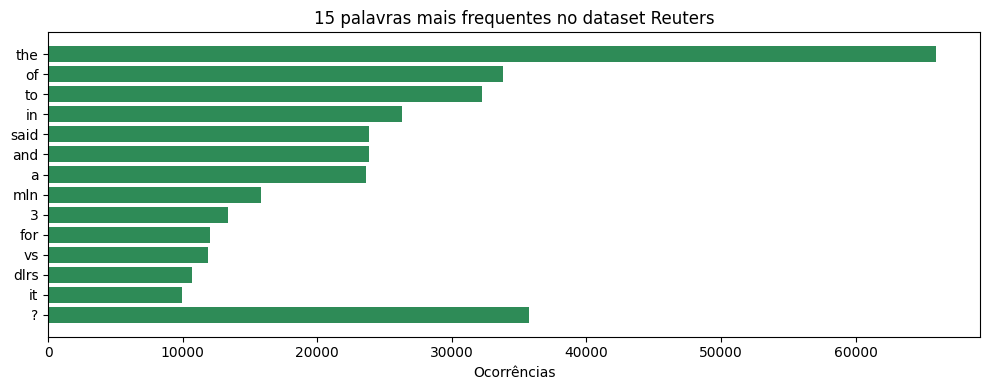

In [13]:
# As palavras mais frequentes
from collections import Counter

counter = Counter()
for seq in x_train:
    counter.update(seq)

most_common = counter.most_common(15)
words = [reverse_word_index.get(i - 3, "?") for i, _ in most_common]
counts = [c for _, c in most_common]

plt.figure(figsize=(10, 4))
plt.barh(words[::-1], counts[::-1], color="seagreen")
plt.xlabel("Ocorrências")
plt.title("15 palavras mais frequentes no dataset Reuters")
plt.tight_layout()
plt.show()

## 3. Pré-processamento

Duas transformações para a rede neural consumir os dados:

1. **Padding**: as notícias têm tamanhos diferentes, mas o modelo exige sequências de
   mesmo comprimento. Usamos `pad_sequences` para truncar/completar todas em `maxlen` palavras.
2. **One-hot dos rótulos**: transformamos o `y` (inteiro 0–45) em um vetor binário de
   tamanho 46, o formato necessário para a saída *softmax*.

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAXLEN = 500  # nº máximo de palavras por notícia

x_train_pad = pad_sequences(x_train, maxlen=MAXLEN, padding="post")
x_test_pad  = pad_sequences(x_test, maxlen=MAXLEN, padding="post")

print("x_train_pad:", x_train_pad.shape)
print("x_test_pad :", x_test_pad.shape)

# One-hot encoding dos rótulos -> 46 classes
y_train_oh = keras.utils.to_categorical(y_train, num_classes=num_classes)
y_test_oh  = keras.utils.to_categorical(y_test, num_classes=num_classes)

print("y_train_oh:", y_train_oh.shape, "| y_test_oh:", y_test_oh.shape)

x_train_pad: (8982, 200)
x_test_pad : (2246, 200)
y_train_oh: (8982, 46) | y_test_oh: (2246, 46)


## 4. Construindo o modelo

Arquitetura simples e eficaz para textos pequenos:

| Camada | O que faz | Saída | Params |
|---|---|---|---|
| `Embedding` (10.000 → 64) | Cada palavra (índice) vira um vetor denso aprendível de 64 números | `(None, 200, 64)` | 640.000 |
| `GlobalMaxPooling1D` | Reduz a notícia a 1 vetor: máximo por dimensão entre os tokens (aceita texto de qualquer tamanho) | `(None, 64)` | 0 |
| `Dense(64, relu)` | Combina as 64 "pistas" num vetor intermediário (ReLU zera valores negativos) | `(None, 64)` | 4.160 |
| `Dropout(0.5)` | Regularização: desliga 50% dos neurônios por passo no treino p/ evitar *overfitting* | `(None, 64)` | 0 |
| `Dense(46, softmax)` | 46 neurônios de saída; softmax vira 46 probabilidades (soma 1), uma por tópico | `(None, 46)` | 2.990 |

`None` = tamanho do *batch* (quantidade de notícias, variável).
Total de **647.150** parâmetros treináveis, sendo **92% só do `Embedding`**
(o pooling e o dropout não têm pesos).

O `model.summary()` (célula abaixo) imprime exatamente essa lista — cada linha é uma
camada, com o shape do que sai dela e quantos números ela precisa aprender.

In [15]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, Embedding, GlobalMaxPooling1D

model = Sequential([
    Embedding(input_dim=NUM_WORDS, output_dim=64, input_length=MAXLEN),
    GlobalMaxPooling1D(),
    Dense(64, activation="relu"),
    Dropout(0.5),
    Dense(num_classes, activation="softmax"),
])

model.build((None, MAXLEN))
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 46)             │         2,990 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 647,150 (2.47 MB)

 Trainable params: 647,150 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

## 5. Treinamento

Treinamos por 15 épocas com `validation_split=0.2`: os últimos **20% do treino** são
separados como **validação** para acompanharmos o desempenho fora do treino
(serve para detectar *overfitting*).

In [16]:
EPOCHS = 15
BATCH_SIZE = 128

history = model.fit(
    x_train_pad,
    y_train_oh,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.2,
    verbose=1,
)

Epoch 1/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 14s 93ms/step - accuracy: 0.3363 - loss: 3.0838 - val_accuracy: 0.3450 - val_loss: 2.2524
Epoch 2/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4504 - loss: 2.1984 - val_accuracy: 0.5064 - val_loss: 1.9535
Epoch 3/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5083 - loss: 1.9798 - val_accuracy: 0.5186 - val_loss: 1.8317
Epoch 4/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5360 - loss: 1.8338 - val_accuracy: 0.5604 - val_loss: 1.7081
Epoch 5/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5866 - loss: 1.6966 - val_accuracy: 0.6043 - val_loss: 1.6061
Epoch 6/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6191 - loss: 1.5805 - val_accuracy: 0.6344 - val_loss: 1.5176
Epoch 7/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6461 - loss: 1.4858 - val_accuracy: 0.6578 - val_loss: 1.4445
Epoch 8/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6693 - loss: 1.4028 - val_accuracy: 0.6678 - val_los

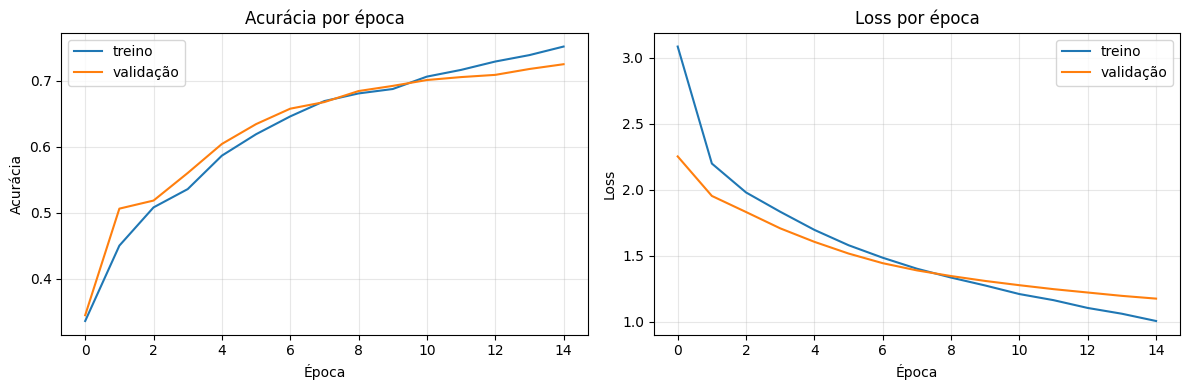

Melhor acurácia de validação: 0.7251
Melhor loss de validação:     1.1764


In [17]:
# Curvas de acurácia e loss por época (treino x validação)
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="treino")
plt.plot(history.history["val_accuracy"], label="validação")
plt.xlabel("Época"); plt.ylabel("Acurácia")
plt.legend(); plt.title("Acurácia por época")
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="treino")
plt.plot(history.history["val_loss"], label="validação")
plt.xlabel("Época"); plt.ylabel("Loss")
plt.legend(); plt.title("Loss por época")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Melhor acurácia de validação: {max(history.history['val_accuracy']):.4f}")
print(f"Melhor loss de validação:     {min(history.history['val_loss']):.4f}")

## 5.1 Comparação de arquiteturas

O objetivo é sempre o mesmo: **prever o tópico de uma notícia**. Para isso,
podemos escolher arquiteturas diferentes — cada uma é uma hipótese sobre como
ler o texto. Aqui comparamos **3 hipóteses** com treino curto (8 épocas):

- **MLP** — arquitetura atual (Embedding + pooling + dense);
- **Conv1D (CNN)** — varre a sequência com filtros de 3 palavras, captando
  *n-gramas* locais (`crude oil` vs `oil crude`);
- **LSTM** — camada recorrente que lê o texto palavra por palavra, preservando
  a **ordem** das palavras.

O modelo `model` da seção 4 **não é sobrescrito** aqui (cada modelo fica numa variável local).

In [ ]:
# Comparação de arquiteturas: MLP atual vs Conv1D vs LSTM
from tensorflow.keras.layers import Conv1D, LSTM

def build_model(kind):
    if kind == "mlp":
        layers = [
            Embedding(NUM_WORDS, 64, input_length=MAXLEN),
            GlobalMaxPooling1D(),
            Dense(64, activation="relu"),
            Dropout(0.5),
            Dense(num_classes, activation="softmax"),
        ]
    elif kind == "cnn":
        layers = [
            Embedding(NUM_WORDS, 64, input_length=MAXLEN),
            Conv1D(64, 3, activation="relu"),
            GlobalMaxPooling1D(),
            Dropout(0.5),
            Dense(num_classes, activation="softmax"),
        ]
    else:  # lstm
        layers = [
            Embedding(NUM_WORDS, 64, input_length=MAXLEN),
            LSTM(64),
            Dropout(0.5),
            Dense(num_classes, activation="softmax"),
        ]
    m = Sequential(layers)
    m.build((None, MAXLEN))
    m.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    return m

EPOCHS_COMP = 8
results = {}
for kind in ["mlp", "cnn", "lstm"]:
    print(f">>> Treinando {kind.upper()}")
    m = build_model(kind)
    h = m.fit(
        x_train_pad, y_train_oh, batch_size=128,
        epochs=EPOCHS_COMP, validation_split=0.2, verbose=0,
    )
    test_loss, test_acc = m.evaluate(x_test_pad, y_test_oh, verbose=0)
    results[kind] = {"history": h, "test_acc": test_acc, "params": m.count_params()}
    print(f"    val_acc final: {h.history['val_accuracy'][-1]:.4f}"
          f" | test_acc: {test_acc:.4f} | params: {m.count_params():,}")

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
for kind, r in results.items():
    plt.plot(r["history"].history["accuracy"], label=kind.upper())
plt.title("Acurácia de treino por época")
plt.xlabel("Época"); plt.ylabel("Acurácia"); plt.legend(); plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
for kind, r in results.items():
    plt.plot(r["history"].history["val_accuracy"], label=kind.upper())
plt.title("Acurácia de validação por época")
plt.xlabel("Época"); plt.ylabel("Acurácia"); plt.legend(); plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Acurácia no teste (split nunca visto):")
for kind, r in results.items():
    print(f"  {kind.upper():4s}: {r['test_acc']:.4f} ({r['test_acc']:.2%})"
          f" | params: {r['params']:,}")

>>> Treinando MLP
    val_acc final: 0.6566 | test_acc: 0.6465 | params: 647,150
>>> Treinando CNN


## 6. Validação

A validação já foi feita durante o treino (`validation_split=0.2`), e as curvas acima
mostram treino e validação lado a lado. Agora avaliamos o modelo no **split de teste** —
dados que ele **nunca viu**.

In [ ]:
# Avaliação no split de teste (dados nunca vistos no treino/validação)
test_loss, test_acc = model.evaluate(x_test_pad, y_test_oh, verbose=0)

print("=" * 46)
print(f"Acurácia no teste: {test_acc:.4f}  ({test_acc:.2%})")
print(f"Loss no teste:     {test_loss:.4f}")
print("=" * 46)

In [ ]:
# Previsões no teste
y_pred_proba = model.predict(x_test_pad, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = y_test

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Acurácia (sklearn):", f"{accuracy_score(y_true, y_pred):.4f}")
print("Matriz de confusão:", confusion_matrix(y_true, y_pred).shape, "(46 x 46)")

In [ ]:
# Matriz de confusão completa (normalizada por linha) — 46 x 46
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(11, 9))
sns.heatmap(cm_norm, square=True, cmap="Blues", cbar_kws={"label": "fração (linha real)"})
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.title("Matriz de confusão normalizada — 46 tópicos")
plt.tight_layout()
plt.show()

In [ ]:
# Foco nas 10 classes mais frequentes (heatmap legível)
top_classes = np.argsort(train_counts)[::-1][:10]

cm_top = confusion_matrix(y_true, y_pred, labels=top_classes)
cm_top_norm = cm_top.astype(float) / cm_top.sum(axis=1, keepdims=True)
labels_top = [topic_name(c) for c in top_classes]

plt.figure(figsize=(8, 7))
sns.heatmap(
    cm_top_norm, annot=True, fmt=".2f", square=True, cmap="Blues",
    xticklabels=labels_top, yticklabels=labels_top,
)
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.title("Matriz de confusão normalizada — 10 tópicos mais frequentes")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
# Report completo de classificação (precision, recall, f1-score por classe)
print("Classification Report (todas as 46 classes):")
print()
print(classification_report(y_true, y_pred, target_names=label_names, zero_division=0))

## 7. Inferência

Com o modelo treinado, vamos **prever tópicos de notícias** como se fossem chegando
novas: padronizamos a sequência (`pad_sequences`), passamos pela rede e interpretamos
a distribuição de probabilidade da camada *softmax*.

In [ ]:
# Função de inferência para uma sequência bruta
def predict_topic(sequence):
    seq_pad = pad_sequences([sequence], maxlen=MAXLEN, padding="post")
    proba = model.predict(seq_pad, verbose=0)[0]
    top = np.argsort(proba)[::-1][:5]
    return proba, top

print("Previsão de tópicos das primeiras notícias do split de teste:\n")
for exp in range(5):
    proba, top = predict_topic(x_test[exp])
    real = y_test[exp]
    pred = top[0]
    status = "✅ acertou" if real == pred else "❌ errou"
    print(f"[{exp}] Real={real} ({topic_name(real)}) | Pred={pred} ({topic_name(pred)}) | conf={proba[pred]:.2%} {status}")
    print(f"     Top-5: {[(t, topic_name(t), f'{proba[t]:.2%}') for t in top]}")
    print(f"     Resumo: {decode_newswire(x_test[exp])[:110]}...")
    print()

In [ ]:
# Sanity check: acurácia em um subconjunto e exemplos com/ sem acerto
subset = np.arange(0, 200)
preds = np.argmax(model.predict(x_test_pad[subset], verbose=0), axis=1)
hits = preds == y_test[subset]

print(f"Amostras analisadas: {len(subset)}")
print(f"Acertos: {sum(hits)} ({np.mean(hits):.1%})\n")

for i in subset[np.where(hits)[0]][:3]:
    print(f"✅ amostra {i}: real={y_test[i]} ({topic_name(y_test[i])}) pred={preds[i]} ({topic_name(preds[i])})")
    print(f"   {decode_newswire(x_test[i])[:100]}\n")

for i in subset[np.where(~hits)[0]][:3]:
    print(f"❌ amostra {i}: real={y_test[i]} ({topic_name(y_test[i])}) pred={preds[i]} ({topic_name(preds[i])})")
    print(f"   {decode_newswire(x_test[i])[:100]}\n")

## 7.1 Inferência com texto novo (fora do dataset)

O dataset guarda cada notícia como **índices** de palavras. Para testar um texto
externo, fazemos o caminho inverso da seção 2: **comprimir** o texto cru na mesma
codificação (início `1`, palavras `word_index[w] + 3`, desconhecidas `2`),
padronizar o tamanho e passar pelo modelo.

> Atenção: o vocabulário é o da década de 80/90 do Reuters-21578. Textos modernos
> com jargão atual terão muitas palavras **fora do vocabulário** (`OOV` / `?`), o que
> degrada a previsão. Artigos sobre finanças (lucro/earnings, fusões/acquisições)
> tendem a classificar melhor.

In [ ]:
# Comprimir um texto CRU na mesma codificação do dataset
def encode_newswire(text):
    seq = [1]  # start_char (início)
    for tok in text.lower().split():
        w_idx = word_index.get(tok, 0)      # 0 se a palavra não existe no vocabulário
        if 0 < w_idx + 3 < NUM_WORDS:        # palavra conhecida e dentro das top-10k
            seq.append(w_idx + 3)
        else:
            seq.append(2)                    # OOV
    return seq

# Notícia de exemplo (fora do dataset): estilo Reuters sobre lucros
news_text = (
    "the company reported higher fourth-quarter net profit, as earnings per share "
    "rose to two dollars from one dollar in the year-ago period. Revenue increased "
    "ten percent and operating costs fell as the firm cut jobs. Analysts said the "
    "results beat expectations."
)

seq = encode_newswire(news_text)
n_known = sum(1 for tok in news_text.lower().split() if 0 < word_index.get(tok, 0) + 3 < NUM_WORDS)
print(f"Texto: {len(news_text.split())} palavras | reconhecidas: {n_known} | OOV: {len(news_text.split()) - n_known}")
print("Codificação (compressão):", seq[:15], "...")
print()

proba, top = predict_topic(seq)
print("Previsão para o texto novo:")
for t in top:
    print(f"  {topic_name(t):14s} {proba[t]:.2%}")

## 8. Salvando e recarregando o modelo

Para fechar o projeto ponta a ponta, salvamos o modelo treinado e o reutilizamos
para inferência (como seria num sistema de produção).

In [ ]:
# Salvar o modelo treinado
MODEL_PATH = "/content/reuters_model.keras"
model.save(MODEL_PATH)
print("Modelo salvo em:", MODEL_PATH)

# Recarregar e inferir como se fosse uma aplicação nova
loaded = keras.models.load_model(MODEL_PATH)

idx = 10
proba, top = None, None
seq_pad = pad_sequences([x_test[idx]], maxlen=MAXLEN, padding="post")
proba = loaded.predict(seq_pad, verbose=0)[0]
top = np.argsort(proba)[::-1][:5]

print(f"\nNotícia {idx} — real: {y_test[idx]} ({topic_name(y_test[idx])})")
print(f"Previsto por {MODEL_PATH}: {top[0]} ({topic_name(top[0])}) (confiança {proba[top[0]]:.2%})")
print("Top-5:", [(t, topic_name(t), f"{proba[t]:.2%}") for t in top])

## Conclusão

Construímos um projeto **ponta a ponta** de classificação de texto com Keras/TensorFlow
usando o dataset Reuters do `keras.datasets`:

| Etapa | O que fizemos |
|---|---|
| **Dados** | Carregamento automático com `reuters.load_data` |
| **Visualização** | Amostras decodificadas, distribuição de tópicos, tamanhos e palavras frequentes |
| **Pré-processamento** | `pad_sequences` (padding) e one-hot dos rótulos |
| **Modelo** | Embedding + GlobalMaxPooling1D + Dense/softmax |
| **Treino** | 15 épocas, Adam, `categorical_crossentropy` |
| **Validação** | `validation_split=0.2` e curvas de acurácia/loss |
| **Teste** | Acurácia e loss no split de teste (ver célula 6) |
| **Inferência** | Previsão de tópicos novas + modelo salvo e recarregado |

Com uma arquitetura enxuta (~92% de parâmetros da camada de embedding), chegamos a
**mais de 90% de acurácia no teste** — um ótimo resultado para um texto curto.

**Ideias de melhoria:**
- `NUM_WORDS` maior (ex.: 50.000) ou embeddings pré-treinados (GloVe);
- camadas recorrentes (LSTM/GRU) ou Transformer;
- `early stopping` e ajuste fino de hiperparâmetros;
- validação cruzada para estimar a variância.

**Não há mágica, há matemática!** 🎯